# 케글 필사

---
## 기본 설정

In [8]:
!pip install kaggle --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kaggle]dk]


In [9]:
!kaggle competitions list

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, gener

In [12]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

kaggle_json = '''{"username":"sumin1130","key":"KGAT_d613e3832969758b3cd7fed2140ec0b2"}'''

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(kaggle_json)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

In [19]:
!kaggle datasets download -d psparks/instacart-market-basket-analysis

Dataset URL: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
License(s): CC0-1.0
instacart-market-basket-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)


In [20]:
!dir

zsh:1: command not found: dir


In [21]:
import zipfile

with zipfile.ZipFile('instacart-market-basket-analysis.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [22]:
import pandas as pd

orders = pd.read_csv('data/orders.csv')
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [23]:
import pandas as pd

orders = pd.read_csv('data/orders.csv')
print(orders.shape)       # (3421083, 7) 이어야 함
print(orders.columns.tolist())

(3421083, 7)
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


In [25]:
orders['order_dow'].unique()

array([2, 3, 4, 1, 5, 0, 6])

In [26]:
orders['order_hour_of_day'].unique()

array([ 8,  7, 12, 15,  9, 14, 16, 11, 10, 19, 18, 17, 13, 20,  0, 21, 22,
        5, 23,  4,  6,  1,  2,  3])

In [27]:
orders['eval_set'].unique()

array(['prior', 'train', 'test'], dtype=object)

---

## 필사 시작

In [28]:
!ls data

aisles.csv                order_products__prior.csv orders.csv
departments.csv           order_products__train.csv products.csv


In [31]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None  # default='warn'

In [32]:
import os
print(os.listdir("data"))

['products.csv', 'orders.csv', 'order_products__train.csv', 'departments.csv', 'aisles.csv', 'order_products__prior.csv']


In [33]:
order_products_train_df = pd.read_csv("data/order_products__train.csv")
order_products_prior_df = pd.read_csv("data/order_products__prior.csv")
orders_df = pd.read_csv("data/orders.csv")
products_df = pd.read_csv("data/products.csv")
aisles_df = pd.read_csv("data/aisles.csv")
departments_df = pd.read_csv("data/departments.csv")

In [37]:
#먼저 모든 파일을 DataFrame 객체로 읽어온 뒤 상위 몇 개 행을 살펴봄
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [39]:
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [36]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


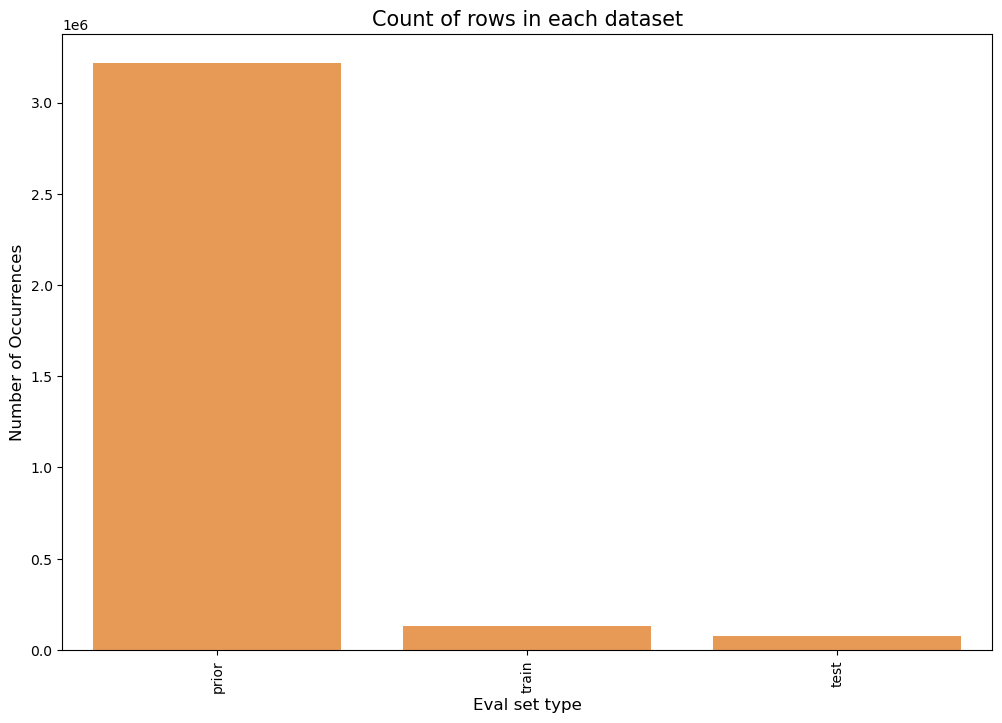

In [38]:
# 어느 소속인지(prior/train/test)인지 알려주는 eval_set
cnt_srs = orders_df.eval_set.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[1])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Eval set type', fontsize=12)
plt.title('Count of rows in each dataset', fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

In [48]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [50]:
orders_df.eval_set.head()

0    prior
1    prior
2    prior
3    prior
4    prior
Name: eval_set, dtype: object

In [51]:
def get_unique_count(x):
    return len(np.unique(x))

cnt_srs = orders_df.groupby("eval_set")["user_id"].aggregate(get_unique_count)
cnt_srs

eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64